# ESA CHANGE - Experiments with data and Random Forest 

## Installation
- Run using this environment (for now): /data/abitibi1/scratch/scratch_disk/pim/miniforge3/envs/phyto-cci-pig

## Initialisation

In [9]:
# Setup and constants

# Import external packages
import numpy as np
import xarray as xr
from   netCDF4 import Dataset
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import pandas as pd
import math
import glob
import seaborn as sns
import sys
import os
from   tqdm.auto import tqdm
from   dask.diagnostics import ProgressBar
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from   pyproj import Transformer
import cdsapi
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from datetime import timedelta
import itertools
import zipfile
from scipy.ndimage import distance_transform_edt
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re
import subprocess

# Import PML packages
# sys.path.append("/users/rsg/anla/code/satellite/match-maker/")
# from match_maker import extract

# Constants
KELVIN_TO_CELSIUS = -273.15
MRLC_VERSION_MAP = {year: "v2_0_7cds" if year <= 2015 else "v2_1_1"
            for year in range(1992, 2030)}

obs_data_root = '/data/datasets/Projects/CHANGE/data'
plots_root = os.path.join(obs_data_root, 'outputs', 'plots')
era5_cache = os.path.join(obs_data_root, 'cache', 'era5')
landcov_cache = os.path.join(obs_data_root, 'cache', 'landcov')
mhw_cache = os.path.join(obs_data_root, 'cache', 'noaa_mhw')

# Initialisation
os.makedirs(plots_root, exist_ok=True)
tqdm.pandas()

# Slice for neighbourhood average
lat_pad = lon_pad = 0.02  # half width of neighbourhood in degrees, so 0.02 gives ~5x5 km.
time_pad = pd.Timedelta(days=2)

# Time lags
lag_precip = [1, 2, 4, 7]
lag_sst = lag_precip
lag_chl = lag_precip

# Restore all variables from store
%store -r
%store

Stored variables and their in-db values:
chl_da                      -> <xarray.DataArray 'chlor_a' (time: 5844, lat: 4320
landcov_da                  -> <xarray.DataArray 'lccs_class' (time: 11, lat: 208
mhw_fill_da                 -> <xarray.DataArray 'heatwave_category' (time: 4910,
obs_df                      ->               EUBWID                    label     
obs_filtered_df             ->               EUBWID                         label
sst_da                      -> <xarray.DataArray 'analysed_sst' (time: 5913, lat:
tp_mm_daily_da              -> <xarray.DataArray 'tp_daily_mm' (time: 2471, lat: 


### Function definitions

In [10]:
# Functions for extracting ERA5 datasets on the fly from Copernicus Data Store.
# Note that you need to have cached username/password credentials set up for this to work.

def download_era5_subset(date, area, filename, client=None):
    """
    Download ERA5 precipitation for a given day and bounding box.
    area = [North, West, South, East] (degrees, lon in 0-360)
    Returns True on failure, False on success.
    """
    if client is None:
        client = cdsapi.Client(quiet=True, timeout=60,)   # Suppress verbose output from the API client

    try: 
        client.retrieve(
            "reanalysis-era5-single-levels",
            # "reanalysis-era5-single-levels-timeseries",   # Zarr version, supposedly faster but not working for some reason
            {
                "product_type": "reanalysis",
                "variable": "total_precipitation",
                "year": date.strftime("%Y"),
                "month": date.strftime("%m"),
                "day": date.strftime("%d"),
                # Requests all the hours of day for good temporal matching, though this may be slowing it down?
                "time": [f"{h:02d}:00" for h in range(24)],
                "area": area,       # TL, BR: lat_max, lon_min, lat_min, lon_max
                "format": "netcdf",
            },
            filename
        )
    except Exception as e:
        print(f"Warning: Failed to download ERA5 data for {date} with area {area}. Error: {e}")
        return True  # Indicate failure
    
    return False  # Indicate success


def download_era5_subset_daily_year(date_from, date_to, area, filename, client=None):
    """
    Download ERA5 precipitation for a given day and bounding box.
    area = [North, West, South, East] (degrees, lon in 0-360)
    Returns True on failure, False on success.
    """
    if client is None:
        client = cdsapi.Client(quiet=True, timeout=60,)   # Suppress verbose output from the API client

    try: 
        client.retrieve(
            "derived-era5-single-levels-daily-statistics",
            {
                "product_type": "reanalysis",
                "variable": "total_precipitation",
                "daily_statistic": "daily_sum",
                "time_zone": "utc+00:00",
                "frequency": "1_hourly",
                "year": f"{date_from.year:04d}",
                "month": [f"{m:02d}" for m in range(date_from.month, date_to.month+1)],
                "day": [f"{d:02d}" for d in range(1, 31+1)],
                "area": area,               # TL, BR: lat_max, lon_min, lat_min, lon_max
                "format": "netcdf",
            },
            filename
        )
    except Exception as e:
        print(f"Warning: Failed to download ERA5 data for {year} with area {area}. Error: {e}")
        return True  # Indicate failure
    
    return False  # Indicate success


def extract_era5_matchups(df, cache_dir="/tmp/change/era5_cache", buffer=0.25, daily=False, time_offset=None, col_name=None):
    """
    Vectorized ERA5 extraction with spatial subsetting.

    Parameters
    ----------
    df : DataFrame
        Must contain columns: 'time', 'lat', 'lon'
    cache_dir : str
        Folder to cache downloaded ERA5 files
    buffer : float
        Spatial padding (degrees)
    day : boolean
        Return daily average instead of instantaneous (hourly)
    time_offset : timedelta
    col_name : specify column name

    Returns
    -------
    DataFrame with tp_mm column
    """

    cache_dir_this = os.path.join(cache_dir, col_name)
    os.makedirs(cache_dir_this, exist_ok=True)
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])
    df["time_ext"] = df["time"]
    if time_offset is not None:
        df["time_ext"] = df["time_ext"] + time_offset

    # Works better using standard lon (-180..180), gave errors when using 0..360.
    # df["lon_era5"] = df["lon"] % 360    # ERA5 uses 0–360 for longitude, so convert if necessary.

    results = []
    client = cdsapi.Client(quiet=True, timeout=60,)   # Suppress verbose output from the API client

    # Process per day, with progress bar (couldn't get that to work)
    # for group in df.groupby(df["time"].dt.date).progress_apply(lambda g: g):
    # Perhaps would have been quicker to group by month, as CDSAPI has a high overhead per request
    for date, group in df.groupby(df["time_ext"].dt.date):

        # if pd.Timestamp(date) == pd.Timestamp('2016-05-17'):
        #     print (f"Skipping {date} due to known ERA5 download issues")
        #     continue
        group = group.copy()

        # Spatial subset bounds (tight bounding box) 
        # Care to calculate min lon before it is converted to 0-360, to avoid issues around grenwich meridian
        lat_max = group["lat"].max() + buffer
        lat_min = group["lat"].min() - buffer
        lon_max = group["lon"].max() + buffer
        lon_min = group["lon"].min() - buffer

        area = [lat_max, lon_min, lat_min, lon_max]

        fname = os.path.join(cache_dir_this, f"era5_{date}.nc")

        # Download once per day (cached)
        if not os.path.exists(fname):
            
            print(f"{pd.to_datetime(pd.Timestamp.now()).strftime('%H:%M:%S')} Downloading {date} for {len(group)} points...", end="")
            if time_offset is not None:
                print(f" (for {pd.Timestamp(group["time"].values[0]).date()})", end="")

            if download_era5_subset(pd.Timestamp(date), area, fname, client=client):
                print(f"Failed to download ERA5 data for {date}. Skipping.")
                continue

        ds = xr.open_dataset(fname)

        # Vectorized selection
        times = xr.DataArray(group["time_ext"].values, dims="points")
        lats  = xr.DataArray(group["lat"].values, dims="points")
        lons  = xr.DataArray(group["lon"].values, dims="points")

        matched = ds.sel(
            valid_time=times,
            latitude=lats,
            longitude=lons,
            method="nearest"
        )

        # Convert rainfall from m to mm
        tp_mm = matched["tp"].values * 1000
        if daily:
            if not col_name:
                col_name = "tp_mm_daily"
            group[col_name] = group["tp_mm"].groupby(group["time_ext"].dt.date).transform("sum")
        else:
            if not col_name:
                col_name = "tp_mm"
            group[col_name] = tp_mm

        results.append(group)
        ds.close()

    results = pd.concat(results).reset_index(drop=True)
    results.drop(column="time_ext")

    return results

def extract_era5_region(df, cache_dir="/tmp/change/era5_cache", buffer=0.25, daily=False, max_offset=None, col_name=None):
    """
    ERA5 extraction of spatial subsetting.

    Parameters
    ----------
    df : DataFrame
        Must contain columns: 'time', 'lat', 'lon'
    cache_dir : str
        Folder to cache downloaded ERA5 files
    buffer : float
        Spatial padding (degrees)
    day : boolean
        Return daily average instead of instantaneous (hourly)
    max_offset : timedelta
    col_name : specify column name

    Returns
    -------
    DataFrame with tp_mm column
    """

    cache_dir_this = os.path.join(cache_dir, col_name)
    os.makedirs(cache_dir_this, exist_ok=True)
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])
    area = [df["lat"].max() + buffer, df["lon"].min() - buffer, df["lat"].min() - buffer, df["lon"].max() + buffer]
    print(f"Extracting ERA5 for region spanning {area[0]:.3f} to {area[2]:.3f} lat, {area[1]:.3f} to {area[3]:.3f} lon")
    
    results = []
    client = cdsapi.Client(quiet=False, debug=False, timeout=60,)   # Suppress verbose output from the API client

    # Loop through years
    for year, ygroup in df.groupby(df["time"].dt.year):
        year_span = [ygroup.time.min().date(), ygroup.time.max().date()]
        year_span[0] = year_span[0] + max_offset    # Max negative offset
        print(f"{pd.to_datetime(pd.Timestamp.now()).strftime('%H:%M:%S')} Processing {year}, spanning {year_span[0]} to {year_span[1]}...")

        fname = os.path.join(cache_dir_this, f"era5_{year}.nc")

        # Download once per year (cached)
        if not os.path.exists(fname):
            
            print(f"{pd.to_datetime(pd.Timestamp.now()).strftime('%H:%M:%S')} Downloading {year}...")

            if download_era5_subset_daily_year(year_span[0], year_span[1], area, fname, client=client):
                print(f"Failed to download ERA5 data for {year}. Skipping.")
                continue
    
    return results
"""
Download a regional subset of ESA CCI Land Cover v2.1.1 from Copernicus CDS
using server-side spatial subsetting via the 'area' parameter.

Version notes:
    v2.0.7cds  ->  years 1992–2015
    v2.1.1     ->  years 2016–present
    Both share the same processing chain and can be combined into a
    consistent time series.
"""

def download_mrlc_year(client, year, area, out_dir):

    version = MRLC_VERSION_MAP[year]
    out_path = os.path.join(out_dir, f"ESA_LC_{year}_subset.nc.zip")    # Provided as zip even though we request netcdf

    if os.path.exists(out_path):
        print(f"Already exists, skipping: {os.path.basename(out_path)}")
        return out_path

    client.retrieve(
        "satellite-land-cover",
        {
            "variable":    "all",
            "year":        str(year),
            "version":     version,
            "area":        area,        # [North, West, South, East]
            "data_format": "netcdf",    # 'data_format' replaces 'format' in new CDS API
        },
        out_path,
    )

    return out_path


# Can probably add a distance tolerance to this if I return distances from transform.

def fill_nearest(da, max_distance=None):
    """
    Replace NaNs with the value of the nearest non-NaN cell.

    Parameters
    ----------
    da : xr.DataArray
        2D array with possible NaN values.
    max_distance : float or None
        Maximum distance (in grid cells) to search for a valid neighbour.
        NaN cells farther than this from any valid cell remain NaN.
        If None, all NaNs are filled regardless of distance.

    Returns
    -------
    xr.DataArray
        Array with NaNs replaced where a valid neighbour exists within
        max_distance grid cells (or everywhere if max_distance is None).
    """
    mask = np.isnan(da.values)

    if not mask.any():
        return da.copy()

    distances, nearest_idx = distance_transform_edt(mask, return_indices=True)
    filled_values = da.values[tuple(nearest_idx)]

    if max_distance is not None:
        # Keep original NaN where the nearest valid cell is too far away
        too_far = mask & (distances > max_distance)
        filled_values[too_far] = np.nan

    return xr.DataArray(filled_values, coords=da.coords, dims=da.dims,
                        attrs=da.attrs)
def list_remote_files(url, extension=None, verbose=True, level=0, max_level=999):
    """
    Recursively list files on an Apache/nginx-style directory listing page.

    Args:
        url:       Base URL of the directory (trailing slash optional)
        extension: Optional filter, e.g. '.nc', '.csv'
        verbose:   Print each directory as it's scanned
        level:     Keep track of recursion
        max_level: Maximum level of directory tree

    Returns:
        List of full URLs to matching files.
    """
    if not url.endswith("/"):
        url += "/"

    if verbose:
        print(f"Scanning: {url}")

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    files = []
    for a in soup.find_all("a", href=True):
        href = a["href"]
        # Skip parent-directory links and query strings
        if href.startswith("?") or href.startswith("/") or href == "../":
            continue

        # Only allow links within same tree
        if href.startswith("http") and not url in href:
            continue

        full_url = urljoin(url, href)

        if href.endswith("/") and level < max_level:
            # It's a subdirectory — recurse
            files.extend(list_remote_files(full_url, extension=extension, verbose=verbose, level=level+1, max_level=max_level))
        elif extension is None or href.endswith(extension):
            files.append(full_url)

    return files

## Load global datasets ready for matchups

### SST

In [ ]:
# %%script false --no-raise-error     # Disables this cell

# Open environmental multi-file datasets

env_file_patt = '/data/datasets/sst/esa-cci-sst/v3.0.1/global/1d/20[12]?/??/??/*SST*.nc'
#from dask.distributed import Client
#client = Client(n_workers=20, threads_per_worker=2, memory_limit='10GB')

# Estimate number of files included
print ("Compiling list of dataset files...")
env_file_list = glob.glob(env_file_patt)
print (f'Env dataset contains {len(env_file_list)} files')

print ('Opening multi-file env data, this may take several minutes...')
with ProgressBar():
    env_ds = xr.open_mfdataset(env_file_patt, combine='by_coords', data_vars='all')

# Tried alternative but it still doesn't show progress bar
#with xr.open_mfdataset(env_file_patt, combine='by_coords', data_vars='all', parallel=True, chunks=dict(index=1)) as env_ds, ProgressBar():
#    env_ds.load()  # Force loading to ensure we catch any issues with the files now, while the progress bar is active.
print ('Done')

# match_maker.extract.gridded.nearest(ds, points, k=1, return_distance=False, units='km')

# Tips for using Xarray for matchups:
# https://gis.stackexchange.com/questions/225100/extract-time-series-values-from-a-3d-lon-lat-time-netcdf-file-using-python


print(f'Variables: {list(env_ds.keys())}')
sst_da = env_ds['analysed_sst'] + KELVIN_TO_CELSIUS
display(sst_da)

# Do we have to invert the array? 

### Marine heatwave

In [ ]:
# Download MHW dataset into cache, because there's no THREDDS server
# If I'd known that, I could have omitted list_remote_files and just use wget --accept-regex.
# Currently loading all of 2010s and 2020s, even though it only really needs May-Sep.
env_file_url = 'https://www.star.nesdis.noaa.gov/pub/socd/mecb/crw/data/marine_heatwave/v1.0.1/category/nc/'
env_file_regex = '.*/20[12]\\d/.*\\.nc'

print ("Compiling list of dataset files...")
all_files = list_remote_files(env_file_url, extension=".nc", max_level=1)   # Find all files on website
r = re.compile(env_file_regex)
env_file_list = list(filter(r.match, all_files))   # Subset to the ones we want
print (f'Env dataset contains {len(env_file_list)} files')

# Write list to temp file
list_file = '/tmp/mhw_files.txt'
with open(list_file, 'w') as f:
    for line in env_file_list:
        f.write(f"{line}\n")

# Use wget to download all the MHW files into year directories
subprocess.run(["wget", '--no-verbose', '--no-clobber', 
                '--directory-prefix='+mhw_cache, '--force-directories', '--no-host-directories', '--cut-dirs=9',
                '--input-file='+list_file])

# Use wget to download all the MHW files into year directories using recursive search, not working
# subprocess.run(["wget", '--verbose', '--no-clobber', 
#                 '--directory-prefix='+mhw_cache, '--force-directories', '--no-host-directories', '--cut-dirs=9',
#                 '--recursive', '-levels=2', env_file_url, '-erobots=off', '--accept-regex='+env_file_regex])

In [ ]:
# Correct coordinates and subscene
# The transition to lat/lon dims happens at 01 Jul. 2024
# Perhaps the dimensions were OK anyway?
def rename_dims(ds):
    global obs_df
    if "latdim" in ds.dims and "londim" in ds.dims:
        ds = ds.assign_coords(
            lat=ds["lat"],
            lon=ds["lon"]
        ).swap_dims({"latdim": "lat", "londim": "lon"})
        # da = ds['heatwave_category']
        # da = da.where(da >= 0, other=251)
        # ds = ds.assign(heatwave_category=da)    # Don't think this works.
        # new_vars = {}
        # for v in ds.data_vars:
        #     if ds[v].dtype == "int8":
        #         da = ds[v]
        #         data = da.astype("uint8")
        #         data = data.fillna(251)
        #         data = data.where(da >= 0, other=251)
        #         new_vars[v] = data
        # ds = ds.assign(new_vars) if new_vars else ds
    # Would be clever to check for 1st Jan then print
    if ds.time[0].dt.month == 1 and ds.time[0].dt.day == 1:
        print(f'{ds.time[0].values}')

    # Subscene to roi to avoid memory errors, should probably drop variables too.
    ds = ds.sel(
        lat=slice(obs_df['lat'].min() - lat_pad, obs_df['lat'].max() + lat_pad),
        lon=slice(obs_df['lon'].min() - lon_pad, obs_df['lon'].max() + lon_pad),
    )
    #  Fix strange buggy data -9e18; set anything very negative to missing.
    ds = ds.where(ds["heatwave_category"] > -100)
    return ds

In [ ]:
# Load the MHW files into Xarray
env_file_list_cache = os.path.join(mhw_cache, '????', '*mhw*.nc')

print ('Opening multi-file env data, this may take several minutes...')
# Progress bar shows 100% for every day, useless. Probably due to preprocess script.
#with ProgressBar():
env_ds = xr.open_mfdataset(env_file_list_cache, combine='by_coords', data_vars=['heatwave_category'], preprocess=rename_dims)

print ('Done')

print(f'Variables: {list(env_ds.keys())}')

mhw_da = env_ds['heatwave_category']
display(mhw_da)

%store mhw_da
# Takes 25m

In [ ]:
# Fill gaps in MHW map for easier matchups
# Just does each yearly span to save a lot of time. 
# Oops should have used concat to avoid time gaps and reduce size of 3D array. Retain time dimension in sel.
mhw_max_offset = 5
mhw_da = mhw_da.sel(
    time=slice(obs_df['time'].min() - pd.Timedelta(days=max(lag_sst)) - time_pad, obs_df['time'].max() + time_pad)
)

mhw_fill_da = xr.full_like(mhw_da, fill_value=np.nan)

# Loop through years
for year, ygroup in obs_df.groupby(obs_df["time"].dt.year):
    year_span = [ygroup.time.min().date(), ygroup.time.max().date()]
    year_span[0] = year_span[0] - pd.Timedelta(days=max(lag_sst))
    year_times = mhw_da.sel(time=slice(year_span[0], year_span[1])).time.values

    print(f"\n{pd.to_datetime(pd.Timestamp.now()).strftime('%H:%M:%S')} Processing {year}, spanning {year_span[0]} to {year_span[1]}...")

    # Loop through each time slice and fill missing values with nearest neighbour
    for time in year_times:

        print(f'{pd.Timestamp(time).strftime("%Y-%m-%d")}', end=', ')
        day_da = mhw_da.sel(time=time)
        if day_da.time.size == 0:
            print(f'\n   No env data for {time}')
            continue

        day_da = fill_nearest(day_da, max_distance=mhw_max_offset)     # Fill missing values with nearest non-missing neighbour

        # Write filled slice back into the copy
        mhw_fill_da.loc[dict(time=time)] = day_da.values
    print()

%store mhw_fill_da
mhw_fill_da

# Takes 120m
# Invalid value in cast at 01/07/2024 - bad fill attribute?
# NB Many values are -9e18, but not missing, see Data Wrangler, needs to be fixed. Hacked, believe these are fill values but don't know why happening.


### Chl-a

In [ ]:
# Open Chl-a global dataset, 4km daily - takes 25 mins
# I could go for 1km data, but the other datasets are >= 4km resolution.

env_file_patt = '/data/datasets/CCI/v6.0-release/geographic/netcdf/daily/chlor_a/20[12]?/*.nc'
data_var = 'chlor_a'

# Estimate number of files included
print ("Compiling list of dataset files...")
env_file_list = glob.glob(env_file_patt)
print (f'Env dataset contains {len(env_file_list)} files')

print ('Opening multi-file env data, this may take several minutes...')
with ProgressBar():
    env_ds = xr.open_mfdataset(env_file_patt, combine='by_coords', data_vars=[data_var])
env_ds = env_ds.chunk(time=30)
print(f'Variables: {list(env_ds.keys())}')
chl_da = env_ds[data_var]
chl_da = chl_da.sortby('lat')
display(chl_da)

### Rainfall

In [ ]:
# Extract lagged rainfall data for whole UK for all dates, rather than tiny patches per sample per lag
# Takes days due to queue on CDS

print(f'\nExtracting precipitation matchups...')
max_offset = timedelta(days=-max(lag_precip)*2)
extract_era5_region(obs_df, cache_dir=era5_cache, daily=True, max_offset=max_offset, col_name='tp_daily_region')

In [ ]:
# Open rainfall data - from our own cache

env_file_patt = os.path.join (era5_cache, 'tp_daily_region', '*.nc')
data_var = 'tp'

# Estimate number of files included
print ("Compiling list of dataset files...")
env_file_list = glob.glob(env_file_patt)
print (f'Env dataset contains {len(env_file_list)} files')

print ('Opening multi-file env data, this may take several minutes...')
with ProgressBar():
    env_ds = xr.open_mfdataset(env_file_patt, combine='by_coords', data_vars=[data_var])
env_ds = env_ds.rename({'valid_time': 'time', 'latitude': 'lat', 'longitude': 'lon'})
print(f'Variables: {list(env_ds.keys())}')
# Convert rainfall from m to mm
tp_mm_daily_da = (env_ds['tp'] * 1000).rename('tp_daily_mm')
tp_mm_daily_da = tp_mm_daily_da.sortby('lat')
display(tp_mm_daily_da)

### Land cover

In [ ]:
# Extract ESA Land Cover-CCI  global dataset, 300m, annual
# Catalogue: https://catalogue.ceda.ac.uk/uuid/b382ebe6679d44b8b0e68ea4ef4b701c/
# Have to accept licences on ECMWF site first.

# Bounding box [North, West, South, East] in decimal degrees
area = [obs_df['lat'].max()+lat_pad, obs_df['lon'].min()-lon_pad, obs_df['lat'].min()-lat_pad, obs_df['lon'].max()+lon_pad]
year_range = [obs_df['time'].min().year, obs_df['time'].max().year]

os.makedirs(landcov_cache, exist_ok=True)
client = cdsapi.Client()   # reads ~/.cdsapirc automatically

for year in range(year_range[0], year_range[1]+1):
    print (f"Downloading year {year}...")
    download_mrlc_year(client, year, area, landcov_cache)

print('Finished')

# Takes about 60m
# 2023-24 will become available during 2026

In [ ]:
# Open land cover data - from our own cache

# Unzip files
for file in glob.glob(os.path.join(landcov_cache, '*.zip')):
    print(f"Unzipping {file}...")
    with zipfile.ZipFile(file, 'r') as zip_ref:
        zip_ref.extractall(landcov_cache)

env_file_patt = os.path.join (landcov_cache, '*.nc')
data_var = 'lccs_class'

# Estimate number of files included
print ("Compiling list of dataset files...")
env_file_list = glob.glob(env_file_patt)
print (f'Env dataset contains {len(env_file_list)} files')

print ('Opening multi-file env data, this may take several minutes...')
env_ds = xr.open_mfdataset(env_file_patt, combine='by_coords', data_vars=[data_var])
print(f'Variables: {list(env_ds.keys())}')
landcov_da = env_ds[data_var]
landcov_da = landcov_da.sortby('lat')
display(landcov_da)

## Analysis of gastoenteritis cases (SaS)

In [ ]:
# Load observed locations from CSV file - Surfers Against Sewage data on gastro cases
obs_data_name = os.path.join(obs_data_root, 'Surfers_Against_Sewage', 'sas_gastro_all_cases_23feb2026.csv')

obs_df = pd.read_csv(obs_data_name)
# Looks like 'n/a' are correctly turned into 'NaN' for missing data.

# Rename columns
obs_df.rename(columns={'Long':'lon', 'Lat':'lat'}, inplace=True)

# Correct data types, sometimes floats are read as strings due to n/a values
obs_df['lon'] = np.float32(obs_df['lon'])
obs_df['lat'] = np.float32(obs_df['lat'])

# Remove invalid rows, with missing lat/lon
obs_df = obs_df.dropna(subset=['lon', 'lat'])

# Add time variable, at midday for dates
obs_df['time'] = pd.to_datetime(obs_df['dateenteredwater'], dayfirst=True) + pd.Timedelta(hours=12)
obs_df

In [ ]:
# Try a match-up with SST data

# Build coordinate arrays aligned to the DataFrame index
times = xr.DataArray(pd.DatetimeIndex(obs_df['time']), dims="points")
lats  = xr.DataArray(obs_df['lat'].values, dims="points")
lons  = xr.DataArray(obs_df['lon'].values, dims="points")

# Vectorised extraction
# NB produces a lot of 271.35 (=-2.0 'C?), perhaps many are too far inland (700 missing).
# 271.35 is temperature of Arctic water, I guess at (0,0) if lat/lon are NaN. -54.53K is missing.
print('Extracting matchups from dataset...')
method = 'nearest'
values = sst_da.sel(
    time=times,
    lat=lats,
    lon=lons,
    method=method,
)

# Select then interpolate doesn't work for me (3441 missing?)
# values = (
#     sst_da.sel(time=times, method=method)
#     .interp(lat=lats, lon=lons)
# )

obs_df['sst'] = values
print(f'Missing values: {obs_df['sst'].isnull().sum().sum() / len(obs_df):.1%}')

# Just show selected columns
print(f'Selected columns:')
print_df = pd.concat([obs_df.iloc[:, :6], obs_df.iloc[:, 16:]], axis='columns')
print_df

In [ ]:
%%script false --no-raise-error     # Disables this cell

# Uses slice for neighbourhood average, takes ~20 mins

# You can't use nearest in time if also using a slice in coordinates, so loop through each row of observations.
# Then use time and coords slice. But we should not average in time.
# Actually, why are we adding a slice in time when there should be identical merged coverage every day?
# Then it is taking the mean over 5 days.
# tqdm makes a progress bar according to the rows of points completed.
results = []
for _, row in tqdm(obs_df.iterrows(), total=len(obs_df), desc='Extracting matchups using slice'):
    nhood = sst_da.sel(
        time=slice(row['time'] - time_pad, row['time'] + time_pad),
        lat=slice(row['lat'] - lat_pad, row['lat'] + lat_pad),
        lon=slice(row['lon'] - lon_pad, row['lon'] + lon_pad),
    )
    results.append(float(nhood.mean()))

# Select time first, then slice coords. No, that will use the closest time whether or not region is missing.
# for _, row in tqdm(obs_df.iterrows(), total=len(obs_df), desc='Extracting matchups using xxx'):
#     nhood = (
#         sst_da.sel(time=row['time'], method=method)
#         .sel(
#             lat=slice(row['lat'] - lat_pad, row['lat'] + lat_pad),
#             lon=slice(row['lon'] - lon_pad, row['lon'] + lon_pad),
#         )
#     )
#     results.append(float(nhood.mean()))

# Select time first, then slice coords. No, that will use the closest time whether or not region is missing.
# Nope, doesn't work due to problems with not monotonically increasing?
# for _, row in tqdm(obs_df.iterrows(), total=len(obs_df), desc='Extracting matchups using xxx'):
#     nhood = (
#         sst_da.sel(time=row['time'], method=method, tolerance=pd.Timedelta(days=2))
#         .sel(lat=row['lat'], lon=row['lon'], method=method)
#     )
#     results.append(float(nhood.mean()))

obs_df['sst2'] = results

print(f'Missing values: {obs_df['sst2'].isnull().sum().sum() / len(obs_df):.1%}')


In [ ]:
# Time-lagged SST matchups
lats  = xr.DataArray(obs_df['lat'].values, dims="points")
lons  = xr.DataArray(obs_df['lon'].values, dims="points")

for lag_days in lag_sst:

# Build coordinate arrays aligned to the DataFrame index
    times = xr.DataArray(pd.DatetimeIndex(obs_df['time'] + timedelta(days=-lag_days)), dims="points")
    col_name = f'sst_lag_{lag_days}d'

    # Vectorised extraction
    print(f'\nExtracting SST matchups with {lag_days} days lag..')
    method = 'nearest'
    values = sst_da.sel(
        time=times,
        lat=lats,
        lon=lons,
        method=method,
    )

    # Select then interpolate doesn't work for me (3441 missing?)
    # values = (
    #     sst_da.sel(time=times, method=method)
    #     .interp(lat=lats, lon=lons)
    # )

    obs_df[col_name] = values
    print(f'Missing values: {obs_df[col_name].isnull().sum().sum() / len(obs_df):.1%}')

# Just show selected columns
print(f'Selected columns:')
print_df = pd.concat([obs_df.iloc[:, :6], obs_df.iloc[:, 16:]], axis='columns')
print_df

In [ ]:
# Simple plot of the matchup SST values
plt.plot(obs_df['sst'])
min(obs_df['sst'])

In [ ]:
# Plotting the matchups points on a map, coloured by the SST value
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc = ax.scatter(obs_df['lon'], obs_df['lat'],
                c=obs_df['sst'],     # colour by this column
                cmap='turbo',        # colormap
                s=100,               # marker size
                alpha=0.8,
                transform=ccrs.PlateCarree(),
                zorder=5)

plt.colorbar(sc, ax=ax, label='SST (°C)', shrink=0.6)
ax.set_title('SST-coloured points matchups with SAS gastro cases on map')
plt.tight_layout()
plt.savefig(os.path.join(plots_root, 'sst_gastro_on_map.png'), dpi=150)
plt.show()

In [ ]:
out_data_name = os.path.join(obs_data_root, 'outputs', 'sas_23feb_test_sst.csv')
obs_df.to_csv(out_data_name)

## Analysis of E coli monitoring (EA)

In [ ]:
# Load observed locations from CSV file - EA monitoring data on E coli
obs_data_name = os.path.join(obs_data_root, 'EA_Ecoli', 'ALL_BW_data_2012-2025.csv')

obs_df = pd.read_csv(obs_data_name)

# Transform UK National Grid easting, northing coordinates to lat, lon
# What is difference between 'ngrx' and 'ngrx (values)' columns?
transformer = Transformer.from_crs("epsg:27700", "epsg:4326", always_xy=True)
lons, lats = transformer.transform(obs_df['ngrx'].values, obs_df['ngry'].values)
obs_df['lat'], obs_df['lon'] = lats, lons

# Remove invalid rows, with missing lat/lon
obs_df = obs_df.dropna(subset=['lon', 'lat'])

# Add time variable, at midday for dates
obs_df['time'] = pd.to_datetime(obs_df['sampleTime'])
obs_df

# Restrict data to coastal sites only (not transitional, rivers, etc.)
obs_df = obs_df[obs_df['siteType'] == 'Coastal']

# Store the data with the lat, lon, time columns
out_data_name = os.path.join(obs_data_root, 'EA_Ecoli', 'ALL_BW_data_2012-2025_latlon.csv')
obs_df.to_csv(out_data_name)

### SST matchups

In [ ]:
# Match-up EA E coli with SST data - vectorised (~5 mins)
# Missing values: 8.6% that's not bad, so the coords must usually hit the sea pixels. 

# Build coordinate arrays aligned to the DataFrame index
times = xr.DataArray(pd.DatetimeIndex(obs_df['time']), dims="points")
lats  = xr.DataArray(obs_df['lat'].values, dims="points")
lons  = xr.DataArray(obs_df['lon'].values, dims="points")

print('Extracting matchups from dataset, this may take a while...')

# Vectorised extraction
method = 'nearest'
values = sst_da.sel(
    time=times,
    lat=lats,
    lon=lons,
    method=method,
)
obs_df['sst'] = values

print(f'Missing values: {obs_df['sst'].isnull().sum().sum() / len(obs_df):.1%}')

# Just show selected columns
print(f'Selected columns:')
print_df = pd.concat([obs_df.iloc[:, :6], obs_df.iloc[:, 16:]], axis='columns')
print_df

In [ ]:
%%script false --no-raise-error     # Disables this cell, takes too long

# Match-up EA E coli with SST data
# Day-at-a-time rather than vectorised, to allow neighbourhood average

print('Extracting matchups from dataset...')

# Slightly dodgy as assuming all rows will be processed in time order within groupby.
# So changed to write row by row, but now will take 60h...
obs_df['sst'] = np.nan
grouped = obs_df.groupby(obs_df["time"].dt.date)
for date, group in tqdm(grouped, total=grouped.ngroups, desc='Extracting matchups using slice'):
    param_group = sst_da.sel(time=date, method='nearest', tolerance=pd.Timedelta(days=2))
    for _, row in group.iterrows():
        nhood = param_group.sel(
            lat=slice(row['lat'] - lat_pad, row['lat'] + lat_pad),
            lon=slice(row['lon'] - lon_pad, row['lon'] + lon_pad),
        )
        row['sst'] = float(nhood.mean())    # NB this doesn't work, need to use .loc index thing.

print(f'Missing values: {obs_df['sst'].isnull().sum().sum() / len(obs_df):.1%}')

# Just show selected columns
print(f'Selected columns:')
print_df = pd.concat([obs_df.iloc[:, :6], obs_df.iloc[:, 16:]], axis='columns')
print_df

### Marine heatwave matchups

In [ ]:
# Match-up EA E coli with MHW data - vectorised
for lag_days in [0] + lag_sst:
    if lag_days == 0:
        col_name = 'mhw'
    else:
        col_name = f'mhw_lag_{lag_days}d'

    # Vectorised extraction
    print(f'\nExtracting MHW matchups with {lag_days} days lag..')

    # Build coordinate arrays aligned to the DataFrame index
    times = xr.DataArray(pd.DatetimeIndex(obs_df['time'])+timedelta(days=-lag_days), dims="points")
    lats  = xr.DataArray(obs_df['lat'].values, dims="points")
    lons  = xr.DataArray(obs_df['lon'].values, dims="points")
    
    # Vectorised extraction
    method = 'nearest'
    values = mhw_fill_da.sel(
        time=times,
        lat=lats,
        lon=lons,
        method=method,
    )
    obs_df[col_name] = values

    print(f'Missing values: {obs_df[col_name].isnull().sum().sum() / len(obs_df):.1%}')

# Missing: was 19.4%, so reran using mhw_fill_da after fill_gaps: missing 0%.
# Takes 22m

### Rainfall matchups

In [ ]:
%%script false --no-raise-error     # Disables this cell, obsolete

# Matchup EA data with rainfall - instantaneous, so unlikely to relate
print('Caching and extracting matchups with ERA5 rainfall data, this may take a while...')
obs_df = extract_era5_matchups(obs_df, cache_dir=era5_cache) 
print(f'Missing values: {obs_df['tp_mm'].isnull().sum().sum() / len(obs_df):.1%}')

In [ ]:
%%script false --no-raise-error     # Disables this cell, obsolete

# Matchup EA data with rainfall - daily sum
print('Caching and extracting matchups with ERA5 daily rainfall data, this may take a while...')
obs_df = extract_era5_matchups(obs_df, cache_dir=era5_cache, daily=True) 
print(f'Missing values: {obs_df["tp_mm_daily"].isnull().sum().sum() / len(obs_df):.1%}')

In [ ]:
%%script false --no-raise-error     # Disables this cell, obsolete

# Matchup EA data with lagged rainfall - daily sum
# I think it would have been better to extract the data for whole UK for all dates, rather than tiny patches per sample per lag, 

for lag_days in lag_precip:
    col_name = f'tp_mm_daily_lag_{lag_days}d'

    # Vectorised extraction
    print(f'\nExtracting precipitation matchups with {lag_days} days lag..')
    obs_df = extract_era5_matchups(obs_df, cache_dir=era5_cache, daily=True, time_offset=timedelta(days=-lag_days), col_name=col_name)
    print(f'Missing values: {obs_df[col_name].isnull().sum().sum() / len(obs_df):.1%}')

    # Store results
    %store obs_df

In [ ]:
# Matchup EA data with lagged rainfall - daily sum using cached UK region
for lag_days in [0] + lag_precip:
    if lag_days == 0:
        col_name = 'tp_mm_daily'
    else:
        col_name = f'tp_mm_daily_lag_{lag_days}d'

    # Vectorised extraction
    print(f'\nExtracting precipitation matchups with {lag_days} days lag..')

    # Build coordinate arrays aligned to the DataFrame index
    times = xr.DataArray(pd.DatetimeIndex(obs_df['time'])+timedelta(days=-lag_days), dims="points")
    lats  = xr.DataArray(obs_df['lat'].values, dims="points")
    lons  = xr.DataArray(obs_df['lon'].values, dims="points")
    
    # Vectorised extraction
    method = 'nearest'
    values = tp_mm_daily_da.sel(
        time=times,
        lat=lats,
        lon=lons,
        method=method,
    )
    obs_df[col_name] = values

    print(f'Missing values: {obs_df[col_name].isnull().sum().sum() / len(obs_df):.1%}')
    
# Store results
%store obs_df

### Chl-a matchups

In [ ]:
%%script false --no-raise-error     # Disables this cell, superceded

# Match-up EA E coli with chl-a data - vectorised (~? mins)
# Missing values: 90%! as 'sel' always takes nearest cell, not nearest valid data.

# Build coordinate arrays aligned to the DataFrame index
times = xr.DataArray(pd.DatetimeIndex(obs_df['time']), dims="points")
lats  = xr.DataArray(obs_df['lat'].values, dims="points")
lons  = xr.DataArray(obs_df['lon'].values, dims="points")
method = 'nearest'

# Chop out subscene
print('Making subscene...')
chl_region_da = chl_da.sel(
    time=slice(obs_df['time'].min() - pd.Timedelta(days=max(lag_chl)) - time_pad, obs_df['time'].max() + time_pad),
    lat=slice(obs_df['lat'].min() - lat_pad, obs_df['lat'].max() + lat_pad),
    lon=slice(obs_df['lon'].min() - lon_pad, obs_df['lon'].max() + lon_pad),
)

# Loop through time lags for chl-a, including no lag
for lag_days in lag_chl: # [0] + lag_chl:
    if lag_days == 0:
        col_name = 'chl'
    else:
        col_name = f'chl_lag_{lag_days}d'

    # Vectorised extraction
    # Dask delayed run to enable use of progress bar
    print('Extracting matchups from dataset', end='')
    if lag_days != 0:
        print(f' with {lag_days} days lag', end='')
    print(', this may take a while...')
    interp_delayed = chl_region_da.sel(
        time=times + pd.Timedelta(days=-lag_days),
        lat=lats,
        lon=lons,
        method=method,
    ).load(compute=False)
    with ProgressBar():
        values = interp_delayed.compute()

    obs_df[col_name] = values

    print(f'Missing values: {obs_df[col_name].isnull().sum().sum() / len(obs_df):.1%}')

# Store results
%store obs_df

# Just show selected columns
print(f'Selected columns:')
print_df = pd.concat([obs_df.iloc[:, :6], obs_df.iloc[:, 16:]], axis='columns')
print_df

# Missing values: 90.6, 90.6, 90.1, 90.3... so if they ALL need to be valid per sample then we end up with only n=30!

In [ ]:
# Match-up EA E coli with chl-a data - vectorised (~? mins)
# If missing, it will take the nearest value within NxN neighbourhood.
# This reduced missing values from 90% to 48%, that seems acceptable now, with genuine gaps due to cloud.

chl_max_offset = 5      # pixels (e.g. 5x4=20 km) allowed away from sample location, to handle cloudy/coast missing data
method = 'nearest'

# Chop out subscene
print('Making subscene...')
chl_region_da = chl_da.sel(
    time=slice(obs_df['time'].min() - pd.Timedelta(days=max(lag_chl)) - time_pad, obs_df['time'].max() + time_pad),
    lat=slice(obs_df['lat'].min() - lat_pad, obs_df['lat'].max() + lat_pad),
    lon=slice(obs_df['lon'].min() - lon_pad, obs_df['lon'].max() + lon_pad),
)

# Loop through time lags for chl-a, including no lag
for lag_days in [0] + lag_chl:
    if lag_days == 0:
        col_name = 'chl'
    else:
        col_name = f'chl_lag_{lag_days}d'

    obs_df[col_name] = np.nan
    time_lagged = obs_df["time"] + pd.Timedelta(days=-lag_days)

    print('\nExtracting matchups from dataset', end='')
    if lag_days != 0:
        print(f' with {lag_days} days lag', end='')
    print(', this may take a while...')

    # Group by date so we can use fill_nearest
    for date, group in obs_df.groupby(time_lagged.dt.date):

        print(f'{date}', end=', ')
        day_da = chl_region_da.sel(time=chl_region_da.time.dt.date.isin(date))
        if day_da.time.size == 0:
            print(f'\n   No env data for {date}')
            continue

        day_da = day_da.squeeze('time', drop=True)
        day_da = fill_nearest(day_da, max_distance=chl_max_offset)     # Fill missing values with nearest non-missing neighbour

        # Build coordinate arrays aligned to the DataFrame index
        # times = xr.DataArray(pd.DatetimeIndex(obs_df['time']), dims="points")
        lats  = xr.DataArray(group['lat'].values, dims="points")
        lons  = xr.DataArray(group['lon'].values, dims="points")

        # Vectorised extraction     
        values = day_da.sel(
            lat=lats,
            lon=lons,
            method=method,
        )
        obs_df.loc[group.index, col_name] = values.values

    print('\n')     # End date line
    print(f'Missing values: {obs_df[col_name].isnull().sum().sum() / len(obs_df):.1%}')

# Store results
%store obs_df

# Just show selected columns
print(f'Selected columns:')
print_df = pd.concat([obs_df.iloc[:, :6], obs_df.iloc[:, 16:]], axis='columns')
print_df

# Missing values: 48.5%, ...

### Land cover matchups

In [ ]:
# Matchup EA data with land cover - using cached UK region
# NB This will include points with water class, not useful.
col_name = f'land_cov'

# Vectorised extraction
print(f'\nExtracting land cover matchups..')

# Build coordinate arrays aligned to the DataFrame index
times = xr.DataArray(pd.DatetimeIndex(obs_df['time']), dims="points")
lats  = xr.DataArray(obs_df['lat'].values, dims="points")
lons  = xr.DataArray(obs_df['lon'].values, dims="points")

# Vectorised extraction
method = 'nearest'
values = landcov_da.sel(
    time=times,
    lat=lats,
    lon=lons,
    method=method,
)
obs_df[col_name] = values

print(f'Missing values: {obs_df[col_name].isnull().sum().sum() / len(obs_df):.1%}')

# Store results
%store obs_df

In [ ]:
# Matchup EA data with land cover - using cached UK region - find closest non-water class
col_name = f'land_cov_near'

# Set water classes to missing, then the matchup will find coastal class instead
class_water = 210
landcov_near_da = landcov_da.where(landcov_da != class_water)

# Vectorised extraction
print(f'\nExtracting land cover matchups..')
obs_df[col_name] = obs_df['land_cov']

# Loop through each year group of observations
for year, group in obs_df.groupby(obs_df["time"].dt.year):
    print(f"\n{pd.to_datetime(pd.Timestamp.now()).strftime('%H:%M:%S')} Processing {year}... (n={len(group)})")

    # Extract the land cover map for this year
    land_year = landcov_near_da.sel(time=landcov_da.time.dt.year.isin(year))
    if land_year.time.size == 0:
        print(f'   No land cover data')
        continue
    land_year = land_year.squeeze('time', drop=True)
    land_year = fill_nearest(land_year)     # Fill missing values with nearest non-missing neighbour
    
    # Build coordinate arrays aligned to the DataFrame index
    lats  = xr.DataArray(group['lat'].values, dims="points")
    lons  = xr.DataArray(group['lon'].values, dims="points")
    method = 'nearest'
    values = land_year.sel(
        lat=lats,
        lon=lons,
        method=method,
    )
    obs_df.loc[group.index, col_name] = values.values      # Clever way to write group values to parent dataframe

print(f'Missing values: {obs_df[col_name].isnull().sum().sum() / len(obs_df):.1%}')

# Store results
# %store obs_df

# Missing 50.1% - 'sel' is not finding nearby valid points if target coord is missing, why?
# Just cannot get this to do what I think it should do. Crashes kernel.
# 'sel' finds the nearest coordinate position, not the nearest non-missing value - very confusing.
# Finally found answer in distance transform fill_nearest. 

In [ ]:
# Abritrary threshold of EA E coli data for plotting test
high_ecoli = {'=', '>'}
obs_filtered_df = obs_df[obs_df['escherichiaColiQualifier'].isin(high_ecoli)]
obs_filtered_df

### Plot matchups on map

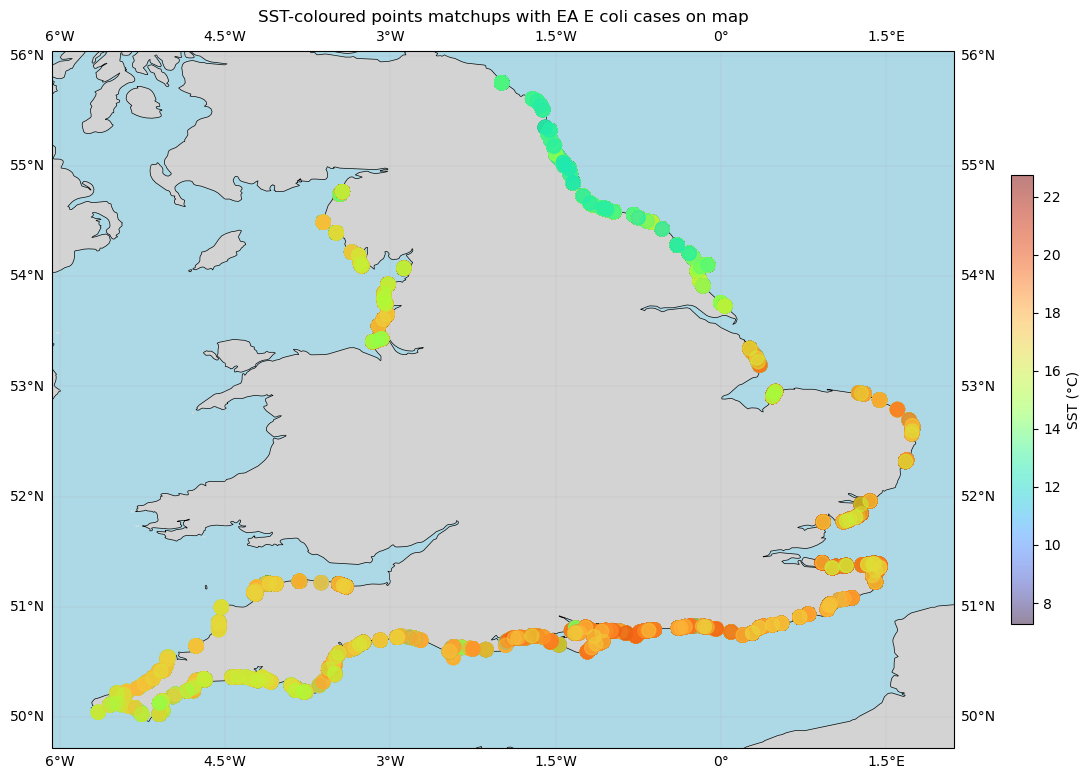

In [11]:
# Plotting the E coli matchups points on a map, coloured by the SST value
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc = ax.scatter(obs_filtered_df['lon'], obs_filtered_df['lat'],
                c=obs_filtered_df['sst'],     # colour by this column
                cmap='turbo',        # colormap
                s=100,               # marker size
                alpha=0.5,
                transform=ccrs.PlateCarree(),
                zorder=5)

plt.colorbar(sc, ax=ax, label='SST (°C)', shrink=0.6)
ax.set_title('SST-coloured points matchups with EA E coli cases on map')
plt.tight_layout()
plt.savefig(os.path.join(plots_root, 'sst_ecoli_on_map.png'), dpi=150)
plt.show()

In [ ]:
# Plotting the E coli matchups points on a map, coloured by the precipitation value
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc = ax.scatter(obs_filtered_df['lon'], obs_filtered_df['lat'],
                c=obs_filtered_df['tp_mm'],     # colour by this column
                cmap='turbo',        # colormap
                s=100,               # marker size
                alpha=0.5,
                transform=ccrs.PlateCarree(),
                zorder=5)

plt.colorbar(sc, ax=ax, label='Total precipitation (mm)', shrink=0.6)
ax.set_title('Precipitation-coloured points matchups with EA E coli cases on map')
plt.tight_layout()
plt.savefig(os.path.join(plots_root, 'tp_ecoli_on_map.png'), dpi=150)
plt.show()

In [ ]:
# Plotting the E coli matchups points on a map, coloured by the chl value
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc = ax.scatter(obs_filtered_df['lon'], obs_filtered_df['lat'],
                c=obs_filtered_df['chl'],     # colour by this column
                cmap='turbo',        # colormap
                s=100,               # marker size
                alpha=0.5,
                transform=ccrs.PlateCarree(),
                zorder=5,
                norm=colors.LogNorm())

cb = plt.colorbar(sc, ax=ax, label='Chl-a (mg m^-3)', shrink=0.6)
cb.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax.set_title('Chl-a-coloured points matchups with EA E coli cases on map')
plt.tight_layout()
plt.savefig(os.path.join(plots_root, 'chl_ecoli_on_map.png'), dpi=150)
plt.show()

In [ ]:
# Test extraction of ERA5 precipitation
df = pd.DataFrame({
    "time": ["2020-01-15 12:30", "2020-01-15 03:10"],
    "lat": [50.4, 51.0],
    "lon": [-4.1, -3.8]
})
out_df = extract_era5_matchups(df)

print(out_df)

### Save matchups for Zenodo

In [ ]:
# Save obs_df to CSV file
matchup_name = os.path.join(obs_data_root, 'outputs', 'change_ea_eng_ecoli_matchups_2012-2025_v1.0.csv')
obs_df.to_csv(matchup_name, index=False)


## Random Forest classification experiments

In [14]:
# Random Forest to predict E coli given SST and ...

# Get the features and lagged versions in a sensible order
lag_names = [f'{v}_lag_{d}d' for v, d in itertools.product(['sst', 'tp_mm_daily', 'mhw'], [0] + lag_precip)]
feature_names = [s.replace('_lag_0d', '') for s in lag_names] + ['chl', 'land_cov_near']
# feature_names = ['sst', 'tp_mm_daily', 'chl', 'land_cov_near', 'mhw'] + lag_names
# feature_names = ['sst', 'tp_mm_daily', 'chl']
# feature_names = ['sst', 'tp_mm_daily', 'chl', 'tp_mm_daily_lag_7d'] + [f'{v}_lag_{d}d' for v, d in itertools.product(['tp_mm_daily'], lag_precip)]
# feature_names = ['tp_mm_daily']

print(f'Using features: {feature_names}')
obs_valid_df = obs_df.dropna(subset=feature_names + ['escherichiaColiCount'])

# Terminology: X is table of features, y is array of values to train and predict
X = obs_valid_df[feature_names]
y = obs_valid_df['escherichiaColiCount'].transpose()

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y
)

# Fit/train a Random Forest classifier
print(f'Fitting Random Forest classifier to {len(X_train)} training samples of {', '.join(feature_names)}...')
clf = RandomForestClassifier(max_depth=None, random_state=0)
clf.fit(X_train, y_train)

Using features: ['sst', 'sst_lag_1d', 'sst_lag_2d', 'sst_lag_4d', 'sst_lag_7d', 'tp_mm_daily', 'tp_mm_daily_lag_1d', 'tp_mm_daily_lag_2d', 'tp_mm_daily_lag_4d', 'tp_mm_daily_lag_7d', 'mhw', 'mhw_lag_1d', 'mhw_lag_2d', 'mhw_lag_4d', 'mhw_lag_7d', 'chl', 'land_cov_near']
Fitting Random Forest classifier to 29701 training samples of sst, sst_lag_1d, sst_lag_2d, sst_lag_4d, sst_lag_7d, tp_mm_daily, tp_mm_daily_lag_1d, tp_mm_daily_lag_2d, tp_mm_daily_lag_4d, tp_mm_daily_lag_7d, mhw, mhw_lag_1d, mhw_lag_2d, mhw_lag_4d, mhw_lag_7d, chl, land_cov_near...


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Predicting for 9901 test samples of sst, sst_lag_1d, sst_lag_2d, sst_lag_4d, sst_lag_7d, tp_mm_daily, tp_mm_daily_lag_1d, tp_mm_daily_lag_2d, tp_mm_daily_lag_4d, tp_mm_daily_lag_7d, mhw, mhw_lag_1d, mhw_lag_2d, mhw_lag_4d, mhw_lag_7d, chl, land_cov_near...


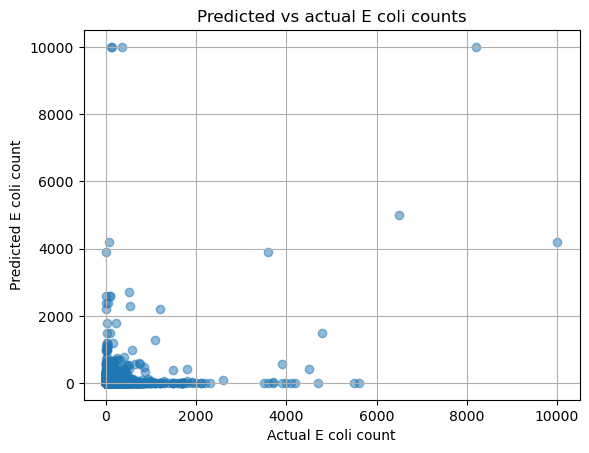

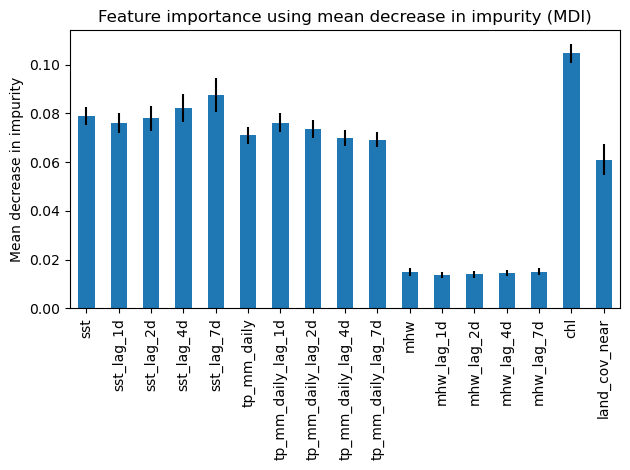

In [15]:
# Predict E coli counts using the trained model

print(f'Predicting for {len(X_test)} test samples of {', '.join(feature_names)}...')
y_result = clf.predict(X_test)

# Plot predicted vs actual E coli counts
plt.scatter(y_test, y_result, alpha=0.5)
plt.xlabel('Actual E coli count')
plt.ylabel('Predicted E coli count')
plt.title('Predicted vs actual E coli counts')
plt.grid(True)
plt.show()

# Feature importance
importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)
forest_importances = pd.Series(importances, index=feature_names)

# Plot feature importances with error bars
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importance using mean decrease in impurity (MDI)")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [16]:
# Now need to evaluate the model performance, e.g. using R^2, MAE, etc.
r2 = clf.score(X_test, y_test)
print(f'R^2 score on test set: {r2:.3f}') 
mae = np.mean(np.abs(y_test - y_result))
print(f'Mean Absolute Error on test set: {mae:.3f}')

R^2 score on test set: 0.628
Mean Absolute Error on test set: 50.840


## Misc commands

In [ ]:
# Store variables so we don't have to regenerate them
%store obs_df obs_filtered_df sst_da chl_da tp_mm_daily_da landcov_da mhw_fill_da

In [ ]:
# Restore all variables from store
%store -r
%store

In [13]:
# Display matchup data
obs_df

,EUBWID,label,sampleTime,intestinalEnterococciQualifier,intestinalEnterococciCount,escherichiaColiQualifier,escherichiaColiCount,siteType,siteType2,Count (values),...,chl_lag_2d,chl_lag_4d,chl_lag_7d,tp_mm_daily_patch,land_cov_near,mhw,mhw_lag_1d,mhw_lag_2d,mhw_lag_4d,mhw_lag_7d
0,ukk3104-33350,Trebarwith Strand,2012-05-01T10:00:00,<,10.0,=,55.0,Coastal,Coastal,204850,...,NaN,1.526842,1.742598,0.141621,130,0.0,0.0,0.0,0.0,0.0
1,ukk3104-33360,Crackington Haven,2012-05-01T10:50:00,=,36.0,=,173.0,Coastal,Coastal,214270,...,NaN,1.495987,2.382100,0.141621,100,0.0,0.0,0.0,0.0,0.0
2,ukk3104-33400,Widemouth Sand,2012-05-01T11:20:00,<,10.0,<,10.0,Coastal,Coastal,219840,...,NaN,2.176867,3.216442,0.141621,150,0.0,0.0,0.0,0.0,0.0
3,ukk3104-33500,Summerleaze,2012-05-01T12:00:00,=,5400.0,=,9000.0,Coastal,Coastal,220380,...,NaN,2.176867,3.216442,0.141621,150,0.0,0.0,0.0,0.0,0.0
4,ukk3104-33600,Crooklets,2012-05-01T11:40:00,=,250.0,=,750.0,Coastal,Coastal,220260,...,NaN,2.176867,3.216442,0.141621,190,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84164,uke1200-08100,Bridlington South Beach,2025-09-28T11:00:00,<,10.0,<,10.0,Coastal,Coastal,517948,...,3.970279,NaN,8.915139,1.855373,200,NaN,0.0,0.0,0.0,0.0
84165,uke1200-08200,Wilsthorpe,2025-09-28T11:25:00,<,10.0,<,10.0,Coastal,Coastal,517407,...,3.970279,NaN,8.915139,1.855373,210,NaN,0.0,0.0,0.0,0.0
84166,uke1200-08300,Fraisthorpe,2025-09-28T11:50:00,<,10.0,<,10.0,Coastal,Coastal,517030,...,4.662061,NaN,8.915139,1.855373,11,NaN,0.0,0.0,0.0,0.0
84167,uke1200-08700,Hornsea,2025-09-28T12:40:00,=,27.0,=,18.0,Coastal,Coastal,520923,...,NaN,5.989252,8.293172,1.855373,210,NaN,0.0,0.0,0.0,1.0


In [ ]:
plt.scatter(obs_df['tp_mm_daily_lag_7d'], obs_df['tp_mm_daily'], alpha=0.1)

times_df = tp_mm_daily_da['time'].values
point = tp_mm_daily_da

In [ ]:
# Store a slice of MHW data for investigating in Data Wrangler
display(mhw_da)
piece = mhw_da.sel(time=slice("2025-06-19", "2025-06-20"))

In [8]:
# Display what is in variable store
%store

Stored variables and their in-db values:
chl_da                      -> <xarray.DataArray 'chlor_a' (time: 5844, lat: 4320
landcov_da                  -> <xarray.DataArray 'lccs_class' (time: 11, lat: 208
mhw_fill_da                 -> <xarray.DataArray 'heatwave_category' (time: 4910,
obs_df                      ->               EUBWID                    label     
obs_filtered_df             ->               EUBWID                         label
sst_da                      -> <xarray.DataArray 'analysed_sst' (time: 5913, lat:
tp_mm_daily_da              -> <xarray.DataArray 'tp_daily_mm' (time: 2471, lat: 
